# 02 - Modelado Supervisado

Implementación de modelos de clasificación con Scikit-learn para predecir el diagnóstico de riesgo (alto/bajo) basado en características de lesiones de piel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report, 
                           confusion_matrix, roc_curve)

# Añadir src al path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocessing import load_processed_data, encode_categorical_features
from model_training import (get_models_dict, train_and_evaluate_model, 
                           save_model, load_model)

# Configuración
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42

## 1. Carga de Datos Procesados

In [2]:
# Cargar datos procesados del notebook anterior
df = load_processed_data()
print(f"Dataset cargado: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado: (1000, 28)
Columnas: ['Edad (años)', 'Sexo', 'Peso (kg)', 'Estatura (cm)', 'IMC (calculado)', 'Tabaquismo', 'Años-paquete', 'Consumo de alcohol', 'Inmunosupresión', 'Exposición solar crónica', 'Antecedentes personales de cáncer', 'Cáncer familiar 1er grado (tipo)', 'Localización de la lesión', 'Tiempo de evolución', 'Tamaño máximo (cm)', 'Dolor', 'Ulceración o sangrado espontáneo', 'Costra persistente', 'Bordes elevados/irregulares', 'Endurecimiento', 'Supuración', 'Cambio reciente de tamaño/color', 'Sutura o manipulación previa', 'Respuesta a antibióticos previos', 'Pérdida de peso involuntaria', 'Fiebre persistente', 'Fatiga', 'diagnostico']


In [3]:
# Ver distribución del target
print("\nDistribución del target:")
print(df['diagnostico'].value_counts())
print(f"\nPorcentaje clase 1: {(df['diagnostico'].sum() / len(df)) * 100:.2f}%")


Distribución del target:
diagnostico
1    990
0     10
Name: count, dtype: int64

Porcentaje clase 1: 99.00%


## 2. Preparación de Datos para Modelado

In [4]:
# Separar features y target
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

print(f"Features: {X.shape[1]}")
print(f"Target: {y.shape}")

Features: 27
Target: (1000,)


In [5]:
# Codificar variables categóricas
X_encoded, encoders = encode_categorical_features(X)

print(f"\nDataset después de codificación: {X_encoded.shape}")
print(f"Columnas numéricas: {X_encoded.shape[1]}")

Columnas codificadas: 16

Dataset después de codificación: (1000, 27)
Columnas numéricas: 27


In [6]:
# División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y  # Mantener proporción del target desbalanceado
)

print(f"\nConjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"\nDistribución en train:\n{y_train.value_counts()}")
print(f"\nDistribución en test:\n{y_test.value_counts()}")


Conjunto de entrenamiento: (800, 27)
Conjunto de prueba: (200, 27)

Distribución en train:
diagnostico
1    792
0      8
Name: count, dtype: int64

Distribución en test:
diagnostico
1    198
0      2
Name: count, dtype: int64


In [7]:
# Escalado de características (importante para algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente")

Datos escalados correctamente


## 3. Definición de Modelos

In [8]:
# Diccionario de modelos a evaluar
models = get_models_dict(random_state=RANDOM_STATE)

print("Modelos definidos:")
for name in models.keys():
    print(f"  - {name}")

Modelos definidos:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - SVM
  - KNN
  - Naive Bayes


## 4. Entrenamiento y Evaluación

In [9]:
# Entrenar y evaluar cada modelo
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Entrenando: {name}")
    print(f"{'='*50}")
    
    # Seleccionar datos según el modelo
    if name in ['SVM', 'KNN', 'Naive Bayes']:
        # Modelos que requieren escalado
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test
    
    # Entrenar y evaluar
    result = train_and_evaluate_model(
        model, name, X_train_use, X_test_use, y_train, y_test
    )
    
    results[name] = result
    
    # Guardar modelo entrenado
    model_dir = os.path.join(os.path.dirname(os.getcwd()), 'models', 'trained_models')
    save_model(model, name, model_dir)
    print(f"Modelo guardado en: {os.path.join(model_dir, f'{name}.joblib')}")


Entrenando: Logistic Regression

Logistic Regression Results:
  Accuracy:  0.9900
  Precision: 1.0000
  Recall:    0.9899
  F1-Score:  0.9949
  ROC-AUC:   0.9949
Modelo guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\logistic_regression.joblib
Modelo guardado en: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Logistic Regression.joblib

Entrenando: Decision Tree

Decision Tree Results:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000
Modelo guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\decision_tree.joblib
Modelo guardado en: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Decision Tree.joblib

Entrenando: Random Forest

Random Forest Results:
  Accuracy:  0.9900
  Precision: 0.9900
  Recall:    1.0000
  F1-Score:  0.9950
  ROC-AUC:   0.5000
Modelo guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\random_forest.joblib
Modelo guardado en: c:

## 5. Comparación de Resultados

In [10]:
# Crear DataFrame con resultados
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("Resumen de Métricas:")
print(results_df.to_string())

Resumen de Métricas:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.990      1.000  0.9899    0.9949   0.9949
Decision Tree           1.000      1.000  1.0000    1.0000   1.0000
Random Forest           0.990      0.990  1.0000    0.9950   0.5000
Gradient Boosting       0.990      0.990  1.0000    0.9950   0.5000
SVM                     0.990      0.990  1.0000    0.9950   0.5000
KNN                     0.990      0.990  1.0000    0.9950   0.5000
Naive Bayes             0.995      0.995  1.0000    0.9975   0.7500


In [11]:
# Guardar resultados
metrics_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'metrics')
results_path = os.path.join(metrics_dir, 'model_comparison_results.csv')
results_df.to_csv(results_path)
print(f"Resultados guardados en: {results_path}")

Resultados guardados en: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\metrics\model_comparison_results.csv


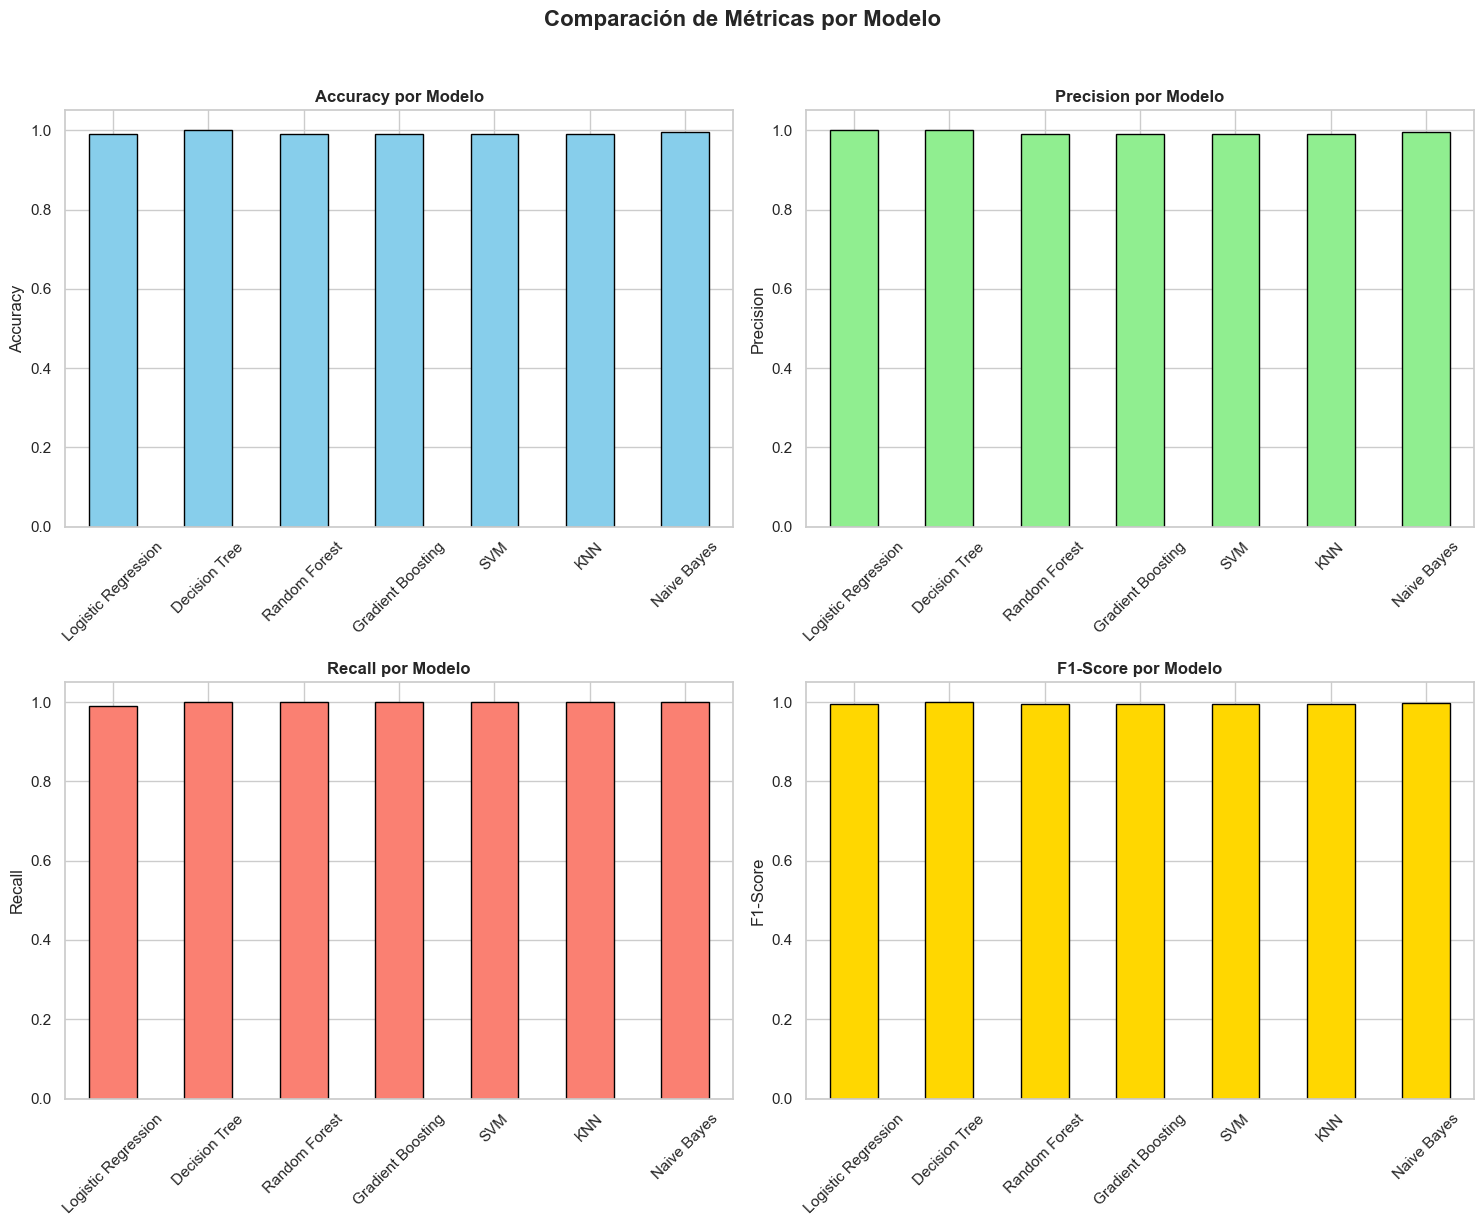

In [12]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
results_df['Accuracy'].plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Accuracy por Modelo', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# Precision
results_df['Precision'].plot(kind='bar', ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Precision por Modelo', fontweight='bold')
axes[0,1].set_ylabel('Precision')
axes[0,1].tick_params(axis='x', rotation=45)

# Recall
results_df['Recall'].plot(kind='bar', ax=axes[1,0], color='salmon', edgecolor='black')
axes[1,0].set_title('Recall por Modelo', fontweight='bold')
axes[1,0].set_ylabel('Recall')
axes[1,0].tick_params(axis='x', rotation=45)

# F1-Score
results_df['F1-Score'].plot(kind='bar', ax=axes[1,1], color='gold', edgecolor='black')
axes[1,1].set_title('F1-Score por Modelo', fontweight='bold')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Comparación de Métricas por Modelo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'plots')
plt.savefig(os.path.join(plots_dir, '12_model_comparison_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Análisis de Curvas ROC

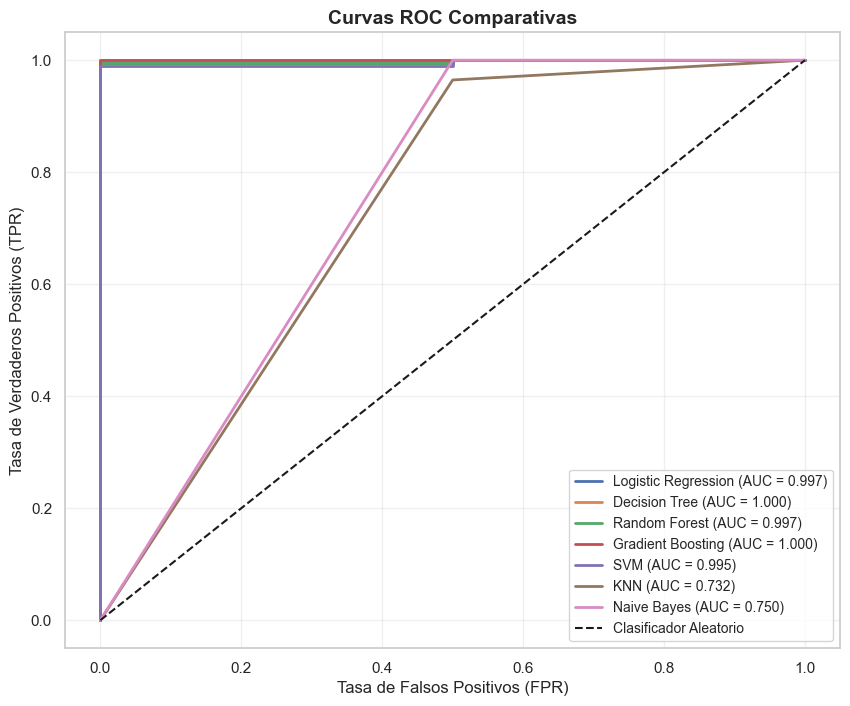

In [13]:
# Calcular curvas ROC para cada modelo
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Seleccionar datos según el modelo
    if name in ['SVM', 'KNN', 'Naive Bayes']:
        X_test_use = X_test_scaled
    else:
        X_test_use = X_test
    
    # Obtener probabilidades
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_use)[:, 1]
    else:
        y_proba = model.decision_function(X_test_use)
    
    # Calcular ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC Comparativas', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

plt.savefig(os.path.join(plots_dir, '13_roc_curves_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Guardar Artefactos del Modelado

In [14]:
# Guardar scaler
scaler_path = os.path.join(os.path.dirname(os.getcwd()), 'models', 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"Scaler guardado: {scaler_path}")

# Guardar encoders
encoders_path = os.path.join(os.path.dirname(os.getcwd()), 'models', 'encoders.joblib')
joblib.dump(encoders, encoders_path)
print(f"Encoders guardados: {encoders_path}")

# Guardar nombres de columnas
columns_path = os.path.join(os.path.dirname(os.getcwd()), 'models', 'feature_columns.joblib')
joblib.dump(list(X_encoded.columns), columns_path)
print(f"Columnas guardadas: {columns_path}")

Scaler guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\scaler.joblib
Encoders guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\encoders.joblib
Columnas guardadas: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\feature_columns.joblib


## Resumen del Modelado

### Modelos entrenados:
1. Regresión Logística
2. Árbol de Decisión
3. Random Forest
4. Gradient Boosting
5. SVM
6. K-Nearest Neighbors
7. Naive Bayes

### Artefactos generados:
- Modelos serializados en `models/trained_models/`
- Scaler y encoders en `models/`
- Métricas comparativas en `results/metrics/`
- Visualizaciones en `results/plots/`

### Próximo paso:
Continuar con `03_model_evaluation.ipynb` para evaluación comparativa detallada.